<a href="https://colab.research.google.com/github/BharathReddyRamasani/AI_DS/blob/main/Encoder_Decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Encoder and Decoder**

## Resources

👉 Build a mini English → French translator using LSTM Encoder–Decoder

Classic Seq2Seq use-case

Covers tokenization, padding, training, inference

Easy to extend later to attention + transformers

1. Load dataset
2. Preprocess text (tokenize, pad)
3. Build Encoder (LSTM)
4. Build Decoder (LSTM)
5. Train model
6. Inference (predict new sentence)

Input Sentence

      ↓
Encoder LSTM

      ↓
Final Hidden State + Cell State

      ↓
Context Vector

      ↓
Decoder LSTM

      ↓
Generate Output Word-by-Word

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense,Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Sample dataset
data = [
    ("i am learning", "je suis en train d apprendre"),
    ("he is running", "il court"),
    ("she is happy", "elle est heureuse"),
    ("i am happy", "je suis heureux")
]

input_texts = [x[0] for x in data]
target_texts = ["<start> " + x[1] + " <end>" for x in data]

**tokenization**

In [ ]:
# Encoder tokenizer
input_tokenizer = Tokenizer()
input_tokenizer.fit_on_texts(input_texts)
input_sequences = input_tokenizer.texts_to_sequences(input_texts)

# Decoder tokenizer
target_tokenizer = Tokenizer(filters='')
target_tokenizer.fit_on_texts(target_texts)
target_sequences = target_tokenizer.texts_to_sequences(target_texts)

In [ ]:
max_input_len = max(len(seq) for seq in input_sequences)
max_target_len = max(len(seq) for seq in target_sequences)

encoder_input_data = pad_sequences(input_sequences, maxlen=max_input_len, padding='post')
decoder_input_data = pad_sequences(target_sequences, maxlen=max_target_len, padding='post')

**create decoder target(shifted)**

In [ ]:
decoder_target_data = np.zeros_like(decoder_input_data)

for i in range(len(data)):
    decoder_target_data[i, :-1] = decoder_input_data[i, 1:]

In [ ]:
vocab_size_input = len(input_tokenizer.word_index) + 1
vocab_size_target = len(target_tokenizer.word_index) + 1
embedding_dim = 50
latent_dim = 100

In [ ]:
encoder_inputs=Input(shape=(None,))
enc_emb=Embedding(vocab_size_input,embedding_dim)(encoder_inputs)

encoder_lstm=LSTM(latent_dim,return_state=True)
_, state_h, state_c = encoder_lstm(enc_emb)
#Encoder understands meaning and stores it in state_h, start_c, These togeather from Context vector
encoder_states = [state_h, state_c]
print(encoder_states)

[<KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_17>, <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>]


In [ ]:
decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(vocab_size_target, embedding_dim)(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

decoder_dense = Dense(vocab_size_target, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

In [ ]:
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

In [ ]:
model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=2,
    epochs=200
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 2.7065
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 2.6832
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.6574
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.6223
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.5819
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.5347
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.4605
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.3427
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.2105
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.9884
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.7916
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.7471
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.7684
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.7632
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.7171
Epoch 16/200
2/2 ━━

In [ ]:
encoder_model=Model(encoder_inputs,encoder_states)
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb2 = Embedding(vocab_size_target, embedding_dim)(decoder_inputs)

decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    dec_emb2, initial_state=decoder_states_inputs
)

decoder_states2 = [state_h2, state_c2]
decoder_outputs2 = decoder_dense(decoder_outputs2)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states2
)

In [ ]:
reverse_target_index = {i: word for word, i in target_tokenizer.word_index.items()}

def decode_sequence(input_seq):

    states_value = encoder_model.predict(input_seq)

    start_token = target_tokenizer.word_index.get('<start>')

    if start_token is None:
        start_token = target_tokenizer.word_index.get('start')

    end_token = target_tokenizer.word_index.get('<end>')

    if end_token is None:
        end_token = target_tokenizer.word_index.get('end')

    target_seq = np.array([[start_token]])

    stop_condition = False
    decoded_sentence = ""

    while not stop_condition:

        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value
        )

        sampled_token_index = np.argmax(output_tokens[0, -1, :])

        sampled_word = reverse_target_index.get(
            sampled_token_index, ''
        )

        if (
            sampled_token_index == end_token or
            len(decoded_sentence.split()) > max_target_len
        ):
            stop_condition = True
        else:
            decoded_sentence += " " + sampled_word

        target_seq = np.array([[sampled_token_index]])

        states_value = [h, c]

    return decoded_sentence

In [ ]:
test_input = "i am happy"
seq = input_tokenizer.texts_to_sequences([test_input])
seq = pad_sequences(seq, maxlen=max_input_len, padding='post')

print("Input:", test_input)
print("Output:", decode_sequence(seq))

Input: i am happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Output:  je suis heureux


Data set Link:
https://www.kaggle.com/datasets/sunnysai12345/news-summary
NEWS SUMMARY | Kaggle
Generating short length descriptions of news articles.

Problem Statement
A software company conducts:
Daily standup meetings
Sprint planning meetings
Client discussions
Project review meetings
Employees don't have time to read long meeting notes.
The company wants an AI system that automatically generates concise summaries.
You are hired as an AI Engineer to build a Seq2Seq Encoder-Decoder based Meeting Notes Summarizer.

Long Meeting Notes

        ↓

Encoder

        ↓

Context Vector

        ↓

Decoder

        ↓

Short Summary


Tasks
Task 1
Perform EDA
Analyze:
number of records
average article length
average summary length

In [ ]:
import kagglehub
import pandas as pd

# Download latest version of the dataset using kagglehub
path = kagglehub.dataset_download("sunnysai12345/news-summary")

print("Path to dataset files:", path)

# Load the dataset using the path provided by kagglehub
# Assuming the main dataset is news_summary.csv within the downloaded path
df = pd.read_csv(f'{path}/news_summary.csv', encoding='latin-1')

print("Dataset Head:")
print(df.head())
print("\nDataset Columns:")
print(df.columns)

# Perform EDA

# Drop rows with any NaN values to ensure accurate length calculations
df.dropna(axis=0, inplace=True)

# 1. Number of records
num_records = len(df)
print(f"\nNumber of records after dropping NaNs: {num_records}")

# 2. Average article length (assuming 'text' column is the article)
df['article_length'] = df['text'].apply(lambda x: len(str(x).split()))
avg_article_length = df['article_length'].mean()
print(f"Average article length (words): {avg_article_length:.2f}")

# 3. Average summary length (assuming 'headlines' column is the summary)
df['summary_length'] = df['headlines'].apply(lambda x: len(str(x).split()))
avg_summary_length = df['summary_length'].mean()
print(f"Average summary length (words): {avg_summary_length:.2f}")

Using Colab cache for faster access to the 'news-summary' dataset.
Path to dataset files: /kaggle/input/news-summary
Dataset Head:
               author                  date  \
0        Chhavi Tyagi  03 Aug 2017,Thursday   
1         Daisy Mowke  03 Aug 2017,Thursday   
2      Arshiya Chopra  03 Aug 2017,Thursday   
3       Sumedha Sehra  03 Aug 2017,Thursday   
4  Aarushi Maheshwari  03 Aug 2017,Thursday   

                                           headlines  \
0  Daman & Diu revokes mandatory Rakshabandhan in...   
1  Malaika slams user who trolled her for 'divorc...   
2  'Virgin' now corrected to 'Unmarried' in IGIMS...   
3  Aaj aapne pakad liya: LeT man Dujana before be...   
4  Hotel staff to get training to spot signs of s...   

                                           read_more  \
0  http://www.hindustantimes.com/india-news/raksh...   
1  http://www.hindustantimes.com/bollywood/malaik...   
2  http://www.hindustantimes.com/patna/bihar-igim...   
3  http://indiatoday.into

## Task 2: Text Preprocessing

In [ ]:
import re

# Lowercase and remove punctuation from 'text' and 'headlines'
def preprocess_text(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation
    return text

df['clean_text'] = df['text'].apply(preprocess_text)
df['clean_headlines'] = df['headlines'].apply(preprocess_text)

print("Original Text Sample:", df['text'].iloc[0])
print("Cleaned Text Sample:", df['clean_text'].iloc[0])
print("\nOriginal Headline Sample:", df['headlines'].iloc[0])
print("Cleaned Headline Sample:", df['clean_headlines'].iloc[0])

Original Text Sample: The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.
Cleaned Text Sample: the administration of union territory daman and diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of rakshabandhan on august 7 the administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media

Original Headline Sample: Daman & Diu revokes mandatory Rakshabandhan in offices order
Cleaned Headline Sample: daman  diu revokes mandatory rakshabandhan in offices order


### Tokenization and Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Prepare input and target texts for tokenization
# Adding <start> and <end> tokens for the decoder target
input_texts_summarizer = df['clean_text'].values
target_texts_summarizer = ["<start> " + text + " <end>" for text in df['clean_headlines'].values]

# Input (Article) Tokenizer
input_tokenizer_summarizer = Tokenizer()
input_tokenizer_summarizer.fit_on_texts(input_texts_summarizer)
encoder_input_sequences_summarizer = input_tokenizer_summarizer.texts_to_sequences(input_texts_summarizer)

# Target (Summary) Tokenizer
target_tokenizer_summarizer = Tokenizer(filters='') # Keep <start> and <end> tokens
target_tokenizer_summarizer.fit_on_texts(target_texts_summarizer)
decoder_input_sequences_summarizer = target_tokenizer_summarizer.texts_to_sequences(target_texts_summarizer)

# Calculate max lengths
max_encoder_seq_len = max(len(seq) for seq in encoder_input_sequences_summarizer)
max_decoder_seq_len = max(len(seq) for seq in decoder_input_sequences_summarizer)

print(f"Max Encoder Sequence Length: {max_encoder_seq_len}")
print(f"Max Decoder Sequence Length: {max_decoder_seq_len}")

# Padding
encoder_input_data_summarizer = pad_sequences(encoder_input_sequences_summarizer, maxlen=max_encoder_seq_len, padding='post')
decoder_input_data_summarizer = pad_sequences(decoder_input_sequences_summarizer, maxlen=max_decoder_seq_len, padding='post')

# Create decoder target data (shifted)
decoder_target_data_summarizer = np.zeros_like(decoder_input_data_summarizer)
for i in range(len(decoder_input_data_summarizer)):
    decoder_target_data_summarizer[i, :-1] = decoder_input_data_summarizer[i, 1:]

# Vocabulary sizes
vocab_size_encoder = len(input_tokenizer_summarizer.word_index) + 1
vocab_size_decoder = len(target_tokenizer_summarizer.word_index) + 1

print(f"Encoder Vocabulary Size: {vocab_size_encoder}")
print(f"Decoder Vocabulary Size: {vocab_size_decoder}")

print("\nEncoder Input Data shape:", encoder_input_data_summarizer.shape)
print("Decoder Input Data shape:", decoder_input_data_summarizer.shape)
print("Decoder Target Data shape:", decoder_target_data_summarizer.shape)

# Display a sample of the processed data
print("\nSample Encoder Input (padded):")
print(encoder_input_data_summarizer[0])
print("Sample Decoder Input (padded):")
print(decoder_input_data_summarizer[0])
print("Sample Decoder Target (padded, shifted):")
print(decoder_target_data_summarizer[0])

Max Encoder Sequence Length: 62
Max Decoder Sequence Length: 16
Encoder Vocabulary Size: 22008
Decoder Vocabulary Size: 9270

Encoder Input Data shape: (4396, 62)
Decoder Input Data shape: (4396, 16)
Decoder Target Data shape: (4396, 16)

Sample Encoder Input (padded):
[    1   965     5   265  2137  8471     6  8472     8  3748    41   289
    11   103    21  2138     9   134     2  3379  8473     2    48  1144
  3380     7     1  2020     5  6699     7   667  1028     1   965    12
   641     2  2287     1   400   318   869   328     5  2450     1  3381
    22    21   286 11804    20   512     6    12   360     7   319   209
     0     0]
Sample Decoder Input (padded):
[   1 2786 2787 2788  615 2789    4 1591  691    2    0    0    0    0
    0    0]
Sample Decoder Target (padded, shifted):
[2786 2787 2788  615 2789    4 1591  691    2    0    0    0    0    0
    0    0]


## Task 3: Build Encoder-Decoder Model for Summarization

In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.models import Model

# Encoder Definition
encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(vocab_size_encoder, embedding_dim, mask_zero=True)(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# Decoder Definition
decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(vocab_size_decoder, embedding_dim, mask_zero=True)(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = Dense(vocab_size_decoder, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Define the Model
model_summarizer = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# Compile the model
model_summarizer.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

print("Summarization Model Summary:")
model_summarizer.summary()

Summarization Model Summary:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, None, 50)  │  1,100,400 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, None)      │          0 │ input_layer_7[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, None, 50)  │    463,500 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 100),     │     60,400 │ embedding_5[0][0… │
│                     │ (None, 100),      │            │ not_equal_2[0][0] │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, None,     │     60,400 │ embedding_6[0][0… │
│                     │ 100), (None,      │            │ lstm_4[0][1],     │
│                     │ 100), (None,      │            │ lstm_4[0][2]      │
│                     │ 100)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, None,      │    936,270 │ lstm_5[0][0]      │
│                     │ 9270)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,620,970 (10.00 MB)

 Trainable params: 2,620,970 (10.00 MB)

 Non-trainable params: 0 (0.00 B)

## Task 5: Train Seq2Seq Model

In [ ]:
import numpy as np
import pandas as pd
import re
import kagglehub
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Data Loading and Preprocessing (moved from previous cells for self-containment) ---

# Download latest version of the dataset using kagglehub
path = kagglehub.dataset_download("sunnysai12345/news-summary")

# Load the dataset using the path provided by kagglehub
df = pd.read_csv(f'{path}/news_summary.csv', encoding='latin-1')

# Drop rows with any NaN values
df.dropna(axis=0, inplace=True)

# Lowercase and remove punctuation from 'text' and 'headlines'
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(preprocess_text)
df['clean_headlines'] = df['headlines'].apply(preprocess_text)

# --- Tokenization and Padding (moved from previous cells for self-containment) ---
input_texts_summarizer = df['clean_text'].values
target_texts_summarizer = ["<start> " + text + " <end>" for text in df['clean_headlines'].values]

input_tokenizer_summarizer = Tokenizer()
input_tokenizer_summarizer.fit_on_texts(input_texts_summarizer)
encoder_input_sequences_summarizer = input_tokenizer_summarizer.texts_to_sequences(input_texts_summarizer)

target_tokenizer_summarizer = Tokenizer(filters='')
target_tokenizer_summarizer.fit_on_texts(target_texts_summarizer)
decoder_input_sequences_summarizer = target_tokenizer_summarizer.texts_to_sequences(target_texts_summarizer)

max_encoder_seq_len = max(len(seq) for seq in encoder_input_sequences_summarizer)
max_decoder_seq_len = max(len(seq) for seq in decoder_input_sequences_summarizer)

encoder_input_data_summarizer = pad_sequences(encoder_input_sequences_summarizer, maxlen=max_encoder_seq_len, padding='post')
decoder_input_data_summarizer = pad_sequences(decoder_input_sequences_summarizer, maxlen=max_decoder_seq_len, padding='post')

decoder_target_data_summarizer = np.zeros_like(decoder_input_data_summarizer)
for i in range(len(decoder_input_data_summarizer)):
    decoder_target_data_summarizer[i, :-1] = decoder_input_data_summarizer[i, 1:]

vocab_size_encoder = len(input_tokenizer_summarizer.word_index) + 1
vocab_size_decoder = len(target_tokenizer_summarizer.word_index) + 1

embedding_dim = 50
latent_dim = 100
# -------------------------------------------------------------------------------------

# Encoder Definition
encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(vocab_size_encoder, embedding_dim, mask_zero=True)(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# Decoder Definition
decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(vocab_size_decoder, embedding_dim, mask_zero=True)(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = Dense(vocab_size_decoder, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Define the Model
model_summarizer = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# Compile the model
model_summarizer.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# Define training parameters
batch_size = 64 # You can adjust this based on your system's memory
epochs = 50 # You can adjust this to achieve better convergence

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the model with Early Stopping
history = model_summarizer.fit(
    [encoder_input_data_summarizer, decoder_input_data_summarizer],
    decoder_target_data_summarizer,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2, # Use 20% of the data for validation
    callbacks=[early_stopping] # Add the Early Stopping callback here
)

print("\nModel training complete!")

100%|██████████| 19.8M/19.8M [00:00<00:00, 110MB/s] 

Extracting files...


Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 8.1162 - val_loss: 7.2125
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 6.8463 - val_loss: 6.9943
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 6.6232 - val_loss: 6.9121
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.4719 - val_loss: 6.8581
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.3572 - val_loss: 6.8418
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.2582 - val_loss: 6.8400
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.1709 - val_loss: 6.8594
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.1226 - val_loss: 6.8756
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.0331 - val_loss: 6.9035
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.9734 - val_loss: 6.9337
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 5.9206 - val_loss: 6.9482

Model training complete!


### Training History

Let's visualize the training and validation loss to understand how the model learned over epochs.

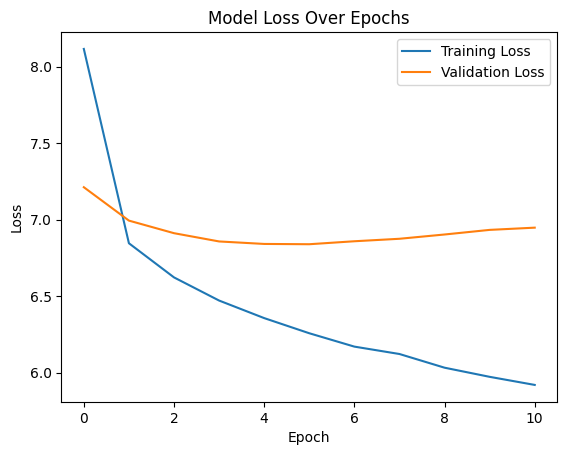

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Task 6: Generate Summary

In [ ]:
# Inference Encoder
inference_encoder_model = Model(encoder_inputs, encoder_states)

# Inference Decoder
decoder_state_input_h_summarizer = Input(shape=(latent_dim,))
decoder_state_input_c_summarizer = Input(shape=(latent_dim,))
decoder_states_inputs_summarizer = [
    decoder_state_input_h_summarizer,
    decoder_state_input_c_summarizer
]

dec_emb_inference = Embedding(
    vocab_size_decoder,
    embedding_dim,
    mask_zero=True
)(decoder_inputs)

decoder_outputs_inference, state_h_inference, state_c_inference = decoder_lstm(
    dec_emb_inference, initial_state=decoder_states_inputs_summarizer
)
decoder_states_inference = [state_h_inference, state_c_inference]
decoder_outputs_inference = decoder_dense(decoder_outputs_inference)

inference_decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs_summarizer,
    [decoder_outputs_inference] + decoder_states_inference
)

print("Inference models defined.")

Inference models defined.


In [ ]:
reverse_target_word_index_summarizer = {
    idx: word for word, idx in target_tokenizer_summarizer.word_index.items()
}
reverse_input_word_index_summarizer = {
    idx: word for word, idx in input_tokenizer_summarizer.word_index.items()
}

def decode_sequence_summarizer(input_seq):
    # Encode the input as state vectors.
    states_value = inference_encoder_model.predict(input_seq)

    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1, 1))

    # Populate the first character of target sequence with the start token.
    start_token_index = target_tokenizer_summarizer.word_index['<start>']
    end_token_index = target_tokenizer_summarizer.word_index['<end>']
    target_seq[0, 0] = start_token_index

    # Sampling loop for a batch of sequences
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = inference_decoder_model.predict(
            [target_seq] + states_value
        )

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = reverse_target_word_index_summarizer.get(
            sampled_token_index, ''
        )

        if sampled_word == '<end>':
            stop_condition = True
        elif len(decoded_sentence.split()) >= max_decoder_seq_len:
            stop_condition = True
        else:
            if sampled_word != '<start>': # Avoid adding <start> to the summary
                decoded_sentence += ' ' + sampled_word

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

        # Update states
        states_value = [h, c]

    return decoded_sentence.strip()

print("Summarizer decode sequence function defined.")

Summarizer decode sequence function defined.


In [ ]:
# Get a random article from the dataset for demonstration
random_idx = np.random.randint(0, len(df))
input_article = df['clean_text'].iloc[random_idx]
original_summary = df['clean_headlines'].iloc[random_idx]

# Preprocess the input article for prediction
input_seq = input_tokenizer_summarizer.texts_to_sequences([input_article])
input_seq = pad_sequences(input_seq, maxlen=max_encoder_seq_len, padding='post')

# Generate summary
generated_summary = decode_sequence_summarizer(input_seq)

print(f"--- Demonstration ---")
print(f"Original Article (cleaned):\n{input_article}")
print(f"\nOriginal Summary (cleaned):\n{original_summary}")
print(f"\nGenerated Summary:\n{generated_summary}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
--- Demonstration ---
Original Article (cleaned):
launching ude desh ka aam nagrik udan scheme on thursday pm narendra modi said my dream was to see a person who wears a hawai chappal slippers to fly on the hawai jahaz aeroplane the lives of the middle class are being transformedearlier aviation was considered to be the domain of a select few that has changed now he added

Original Summary (cleaned):
wanted to see people wearing hawai chappal on hawai jahaz

Generated Summary:
delhi to to to to in


## Model Evaluation: ROUGE Scores

Let's evaluate the model's summarization capability using ROUGE metrics. ROUGE scores compare the generated summary against a reference summary based on overlapping units (words or word sequences).

In [ ]:
import numpy as np
import pandas as pd
import re
import kagglehub
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

try:
    from rouge_score import rouge_scorer
except ImportError:
    print("Installing rouge_score library...")
    !pip install rouge_score
    from rouge_score import rouge_scorer

# --- Data Loading and Preprocessing (copied from 765de815 for self-containment) ---
# Download latest version of the dataset using kagglehub
path = kagglehub.dataset_download("sunnysai12345/news-summary")

# Load the dataset using the path provided by kagglehub
df = pd.read_csv(f'{path}/news_summary.csv', encoding='latin-1')

# Drop rows with any NaN values
df.dropna(axis=0, inplace=True)

# Lowercase and remove punctuation from 'text' and 'headlines'
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(preprocess_text)
df['clean_headlines'] = df['headlines'].apply(preprocess_text)

# --- Tokenization and Padding (copied from 765de815 for self-containment) ---
input_texts_summarizer = df['clean_text'].values
target_texts_summarizer = ["<start> " + text + " <end>" for text in df['clean_headlines'].values]

input_tokenizer_summarizer = Tokenizer()
input_tokenizer_summarizer.fit_on_texts(input_texts_summarizer)
encoder_input_sequences_summarizer = input_tokenizer_summarizer.texts_to_sequences(input_texts_summarizer)

target_tokenizer_summarizer = Tokenizer(filters='')
target_tokenizer_summarizer.fit_on_texts(target_texts_summarizer)
decoder_input_sequences_summarizer = target_tokenizer_summarizer.texts_to_sequences(target_texts_summarizer)

max_encoder_seq_len = max(len(seq) for seq in encoder_input_sequences_summarizer)
max_decoder_seq_len = max(len(seq) for seq in decoder_input_sequences_summarizer)

encoder_input_data_summarizer = pad_sequences(encoder_input_sequences_summarizer, maxlen=max_encoder_seq_len, padding='post')
decoder_input_data_summarizer = pad_sequences(decoder_input_sequences_summarizer, maxlen=max_decoder_seq_len, padding='post')

decoder_target_data_summarizer = np.zeros_like(decoder_input_data_summarizer)
for i in range(len(decoder_input_data_summarizer)):
    decoder_target_data_summarizer[i, :-1] = decoder_input_data_summarizer[i, 1:]

vocab_size_encoder = len(input_tokenizer_summarizer.word_index) + 1
vocab_size_decoder = len(target_tokenizer_summarizer.word_index) + 1

embedding_dim = 50
latent_dim = 100
# -------------------------------------------------------------------------------------

# --- Model Definition (copied from 765de815 and 2f70704d for self-containment) ---
# Encoder Definition
encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(vocab_size_encoder, embedding_dim, mask_zero=True)(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# Decoder Definition
decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(vocab_size_decoder, embedding_dim, mask_zero=True)(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = Dense(vocab_size_decoder, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Define the Model (for training)
model_summarizer = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model_summarizer.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# --- Inference Model Definition (copied from 69718b84 for self-containment) ---
# Inference Encoder
inference_encoder_model = Model(encoder_inputs, encoder_states)

# Inference Decoder
decoder_state_input_h_summarizer = Input(shape=(latent_dim,))
decoder_state_input_c_summarizer = Input(shape=(latent_dim,))
decoder_states_inputs_summarizer = [
    decoder_state_input_h_summarizer,
    decoder_state_input_c_summarizer
]

dec_emb_inference = Embedding(
    vocab_size_decoder,
    embedding_dim,
    mask_zero=True
)(decoder_inputs)

decoder_outputs_inference, state_h_inference, state_c_inference = decoder_lstm(
    dec_emb_inference, initial_state=decoder_states_inputs_summarizer
)
decoder_states_inference = [state_h_inference, state_c_inference]
decoder_outputs_inference = decoder_dense(decoder_outputs_inference)

inference_decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs_summarizer,
    [decoder_outputs_inference] + decoder_states_inference
)

# --- Decode Sequence Function (copied from 70a6a240 for self-containment) ---
reverse_target_word_index_summarizer = {
    idx: word for word, idx in target_tokenizer_summarizer.word_index.items()
}
reverse_input_word_index_summarizer = {
    idx: word for word, idx in input_tokenizer_summarizer.word_index.items()
}

def decode_sequence_summarizer(input_seq):
    # Encode the input as state vectors.
    states_value = inference_encoder_model.predict(input_seq, verbose=0)

    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1, 1))

    # Populate the first character of target sequence with the start token.
    start_token_index = target_tokenizer_summarizer.word_index['<start>']
    end_token_index = target_tokenizer_summarizer.word_index['<end>']
    target_seq[0, 0] = start_token_index

    # Sampling loop for a batch of sequences
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = inference_decoder_model.predict(
            [target_seq] + states_value, verbose=0
        )

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = reverse_target_word_index_summarizer.get(
            sampled_token_index, ''
        )

        if sampled_word == '<end>':
            stop_condition = True
        elif len(decoded_sentence.split()) >= max_decoder_seq_len:
            stop_condition = True
        else:
            if sampled_word != '<start>': # Avoid adding <start> to the summary
                decoded_sentence += ' ' + sampled_word

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

        # Update states
        states_value = [h, c]

    return decoded_sentence.strip()


# Initialize the ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def calculate_rouge_scores(reference_summary, generated_summary):
    scores = scorer.score(reference_summary, generated_summary)
    return {
        'rouge1_fmeasure': scores['rouge1'].fmeasure,
        'rouge2_fmeasure': scores['rouge2'].fmeasure,
        'rougeL_fmeasure': scores['rougeL'].fmeasure,
    }

# Let's evaluate a few random samples
num_evaluation_samples = 10 # You can increase this number for more robust evaluation
eval_indices = np.random.choice(len(df), num_evaluation_samples, replace=False)

all_rouge_scores = []

print(f"\nCalculating ROUGE scores for {num_evaluation_samples} samples...")
for i, idx in enumerate(eval_indices):
    input_article = df['clean_text'].iloc[idx]
    original_summary = df['clean_headlines'].iloc[idx]

    input_seq = input_tokenizer_summarizer.texts_to_sequences([input_article])
    input_seq = pad_sequences(input_seq, maxlen=max_encoder_seq_len, padding='post')
    generated_summary = decode_sequence_summarizer(input_seq)

    rouge_result = calculate_rouge_scores(original_summary, generated_summary)
    all_rouge_scores.append(rouge_result)

    print(f"\n--- Sample {i+1} ---")
    print(f"Original Article: {input_article[:100]}...")
    print(f"Original Summary: {original_summary}")
    print(f"Generated Summary: {generated_summary}")
    print(f"ROUGE Scores: {rouge_result}")

# Calculate average ROUGE scores
if all_rouge_scores:
    avg_rouge1 = np.mean([s['rouge1_fmeasure'] for s in all_rouge_scores])
    avg_rouge2 = np.mean([s['rouge2_fmeasure'] for s in all_rouge_scores])
    avg_rougeL = np.mean([s['rougeL_fmeasure'] for s in all_rouge_scores])
    print(f"\n--- Average ROUGE Scores ({num_evaluation_samples} samples) ---")
    print(f"Average ROUGE-1 F-measure: {avg_rouge1:.4f}")
    print(f"Average ROUGE-2 F-measure: {avg_rouge2:.4f}")
    print(f"Average ROUGE-L F-measure: {avg_rougeL:.4f}")
else:
    print("No ROUGE scores calculated.")


Calculating ROUGE scores for 10 samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

--- Sample 1 ---
Original Article: actor shakti kapoor while speaking on his daughter shraddha kapoors lack of success with her last tw...
Original Summary: shraddha has a rich father she can take it easy shakti 
Generated Summary: delhi to to to to in
ROUGE Scores: {'rouge1_fmeasure': 0.0, 'rouge2_fmeasure': 0.0, 'rougeL_fmeasure': 0.0}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

--- Sa